<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">

# Procesamiento de Lenguaje Natural
## Desafío 4 - Traductor Seq2Seq Inglés → Español

Este notebook resuelve el desafío tomando como base el modelo `Traductor.ipynb` trabajado en clase.

Objetivos implementados:

- Replicar la arquitectura encoder-decoder con LSTM.
- Extender el entrenamiento usando un conjunto de datos más amplio.
- Usar secuencias de mayor longitud que el notebook base.
- Comparar distintas cantidades de unidades LSTM.
- Evaluar el desempeño con `val_loss`, accuracy token-level y perplejidad.
- Generar al menos cinco ejemplos de traducción.
- Interpretar los resultados y limitaciones del enfoque.


## Consigna

Se parte del traductor desarrollado en clase y se realizan extensiones sobre:

1. Cantidad de datos utilizada.
2. Longitud máxima de las secuencias.
3. Número de unidades en las capas LSTM.
4. Evaluación comparativa de modelos.
5. Generación de traducciones de ejemplo.

El problema corresponde a traducción automática palabra a palabra mediante un modelo encoder-decoder recurrente. El encoder procesa la oración en inglés y resume su información en estados internos. El decoder usa esos estados para generar la oración en español token por token.


In [1]:
import os
import zipfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(40)
tf.random.set_seed(40)

print("TensorFlow:", tf.__version__)


I0000 00:00:1781221792.075117    1087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781221792.441831    1087 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781221794.530916    1087 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0


## 1. Preparación del dataset

Se utiliza el dataset `spa-eng`, el mismo del notebook base, pero se amplía la cantidad de oraciones (30.000), permitiendo entrenar el modelo con mayor variabilidad lingüística.


In [2]:
DATASET_PATH = "spa-eng"
ZIP_PATH = "spa-eng.zip"
URL = "http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip"

if not os.path.exists(DATASET_PATH):
    print("Descargando dataset spa-eng...")
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print("Extrayendo dataset...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Dataset descargado y extraído.")

with open(f"./{DATASET_PATH}/spa.txt", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

np.random.shuffle(lines)

MAX_NUM_SENTENCES = 30000

input_sentences = []
target_sentences = []
target_sentences_inputs = []

for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break

    if "\t" not in line:
        continue

    source_text, target_text = line.rstrip().split("\t")[:2]

    input_sentences.append(source_text)
    target_sentences.append(target_text + " <eos>")
    target_sentences_inputs.append("<sos> " + target_text)

print("Pares de oraciones cargados:", len(input_sentences))
print("\nEjemplo:")
print("EN:", input_sentences[0])
print("ES decoder target:", target_sentences[0])
print("ES decoder input :", target_sentences_inputs[0])


Descargando dataset spa-eng...
Extrayendo dataset...
Dataset descargado y extraído.
Pares de oraciones cargados: 30000

Ejemplo:
EN: Somebody stole my car.
ES decoder target: Alguien robó mi auto. <eos>
ES decoder input : <sos> Alguien robó mi auto.


## 2. Tokenización y secuencias

Se tokenizan las oraciones a nivel de palabra. El modelo recibe secuencias de índices enteros.

Para cumplir con la consigna de usar secuencias de mayor longitud, se aumenta el límite respecto del notebook original: secuencias de hasta `30` palabras para inglés y `34` para español. También, se filtran oraciones excesivamente largas para mantener un entrenamiento razonable.



In [ ]:
MAX_VOCAB_SIZE = 10000

# Importante: no filtramos los caracteres < y > para conservar <sos> y <eos>.
TOKEN_FILTERS = '!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n'

input_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters=TOKEN_FILTERS,
    oov_token="<unk>"
)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

target_tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    filters=TOKEN_FILTERS,
    oov_token="<unk>"
)
target_tokenizer.fit_on_texts(target_sentences + target_sentences_inputs)
target_integer_seq = target_tokenizer.texts_to_sequences(target_sentences)
target_input_integer_seq = target_tokenizer.texts_to_sequences(target_sentences_inputs)
word2idx_outputs = target_tokenizer.word_index

# Longitudes modificadas en comparación con el notebook original
MAX_INPUT_LEN_CAP = 30
MAX_TARGET_LEN_CAP = 34

source_lengths = np.array([len(seq) for seq in input_integer_seq])
target_lengths = np.array([len(seq) for seq in target_integer_seq])

# Se elige una longitud alta, pero con cap para no volver demasiado pesado el entrenamiento.
max_input_len = min(MAX_INPUT_LEN_CAP, max(20, int(np.percentile(source_lengths, 95))))
max_out_len = min(MAX_TARGET_LEN_CAP, max(22, int(np.percentile(target_lengths, 95))))

keep_mask = (
    (source_lengths > 0) &
    (target_lengths > 0) &
    (source_lengths <= max_input_len) &
    (target_lengths <= max_out_len)
)

input_sentences = [s for s, keep in zip(input_sentences, keep_mask) if keep]
target_sentences = [s for s, keep in zip(target_sentences, keep_mask) if keep]
target_sentences_inputs = [s for s, keep in zip(target_sentences_inputs, keep_mask) if keep]

input_integer_seq = [s for s, keep in zip(input_integer_seq, keep_mask) if keep]
target_integer_seq = [s for s, keep in zip(target_integer_seq, keep_mask) if keep]
target_input_integer_seq = [s for s, keep in zip(target_input_integer_seq, keep_mask) if keep]

encoder_input_sequences = pad_sequences(
    input_integer_seq,
    maxlen=max_input_len,
    padding="pre",
    truncating="pre"
)

decoder_input_sequences = pad_sequences(
    target_input_integer_seq,
    maxlen=max_out_len,
    padding="post",
    truncating="post"
)

decoder_output_sequences = pad_sequences(
    target_integer_seq,
    maxlen=max_out_len,
    padding="post",
    truncating="post"
)

num_words_encoder = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1)
num_words_decoder = min(MAX_VOCAB_SIZE, len(word2idx_outputs) + 1)

print("Oraciones luego del filtrado:", len(input_sentences))
print("Vocabulario inglés:", len(word2idx_inputs), "| usado:", num_words_encoder)
print("Vocabulario español:", len(word2idx_outputs), "| usado:", num_words_decoder)
print("max_input_len:", max_input_len)
print("max_out_len:", max_out_len)
print("Shape encoder:", encoder_input_sequences.shape)
print("Shape decoder input:", decoder_input_sequences.shape)
print("Shape decoder output:", decoder_output_sequences.shape)

assert "<sos>" in word2idx_outputs, "No se encontró el token <sos>."
assert "<eos>" in word2idx_outputs, "No se encontró el token <eos>."


Oraciones luego del filtrado: 29965
Vocabulario inglés: 8073 | usado: 8074
Vocabulario español: 13955 | usado: 10000
max_input_len: 20
max_out_len: 22
Shape encoder: (29965, 20)
Shape decoder input: (29965, 22)
Shape decoder output: (29965, 22)


## 3. Dataset de entrenamiento y validación

A diferencia del notebook base, se usa `sparse_categorical_crossentropy` en vez de one-hot explícito. Esto reduce mucho el uso de memoria. Además, se aplica una máscara para que el padding `0` no tenga peso en la función de pérdida ni en las métricas.


In [4]:
BATCH_SIZE = 64
VAL_SPLIT = 0.15

split_idx = int(len(encoder_input_sequences) * (1 - VAL_SPLIT))

Xenc_train = encoder_input_sequences[:split_idx]
Xdec_train = decoder_input_sequences[:split_idx]
y_train = decoder_output_sequences[:split_idx]

Xenc_val = encoder_input_sequences[split_idx:]
Xdec_val = decoder_input_sequences[split_idx:]
y_val = decoder_output_sequences[split_idx:]

def make_dataset(enc_seqs, dec_in_seqs, dec_out_seqs, batch_size):
    enc_seqs = enc_seqs.astype("int32")
    dec_in_seqs = dec_in_seqs.astype("int32")
    dec_out_seqs = dec_out_seqs.astype("int32")

    sample_weights = (dec_out_seqs != 0).astype("float32")

    ds = tf.data.Dataset.from_tensor_slices(
        ((enc_seqs, dec_in_seqs), dec_out_seqs, sample_weights)
    )
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(Xenc_train, Xdec_train, y_train, BATCH_SIZE)
val_ds = make_dataset(Xenc_val, Xdec_val, y_val, BATCH_SIZE)

print("Train samples:", len(Xenc_train))
print("Validation samples:", len(Xenc_val))


Train samples: 25470
Validation samples: 4495


W0000 00:00:1781221889.265394    1087 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781221889.362361    1087 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781221889.687912    1087 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5146 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 4. Embeddings

El notebook base utiliza embeddings preentrenados GloVe para el encoder en inglés.

En esta resolución se deja una implementación robusta:

- Si existe el archivo `gloveembedding.pkl`, se usa como embedding preentrenado.
- Si no existe, se entrena el embedding del encoder desde cero.

Esto permite ejecutar el notebook sin depender obligatoriamente de un archivo externo.


In [5]:
EMBED_DIM = 50
GLOVE_PATH = "gloveembedding.pkl"

def try_load_glove_embedding_matrix(path, tokenizer_word_index, nb_words, embed_dim=50):
    if not os.path.exists(path):
        print("No se encontró gloveembedding.pkl. Se entrenará el embedding del encoder desde cero.")
        return None

    try:
        import pickle
        with open(path, "rb") as f:
            embeddings = pickle.loads(f.read())

        idx_array = np.arange(embeddings.shape[0])
        glove_word2idx = dict(zip(embeddings["word"], idx_array))

        matrix = np.zeros((nb_words, embed_dim), dtype="float32")
        hits = 0

        for word, i in tokenizer_word_index.items():
            if i < nb_words:
                idx = glove_word2idx.get(word, -1)
                if idx != -1:
                    matrix[i] = embeddings[idx]["embedding"]
                    hits += 1

        print(f"GloVe cargado. Palabras encontradas: {hits}/{nb_words}")
        return matrix

    except Exception as e:
        print("No se pudo cargar GloVe. Se entrenará el embedding del encoder desde cero.")
        print("Error:", e)
        return None

embedding_matrix = try_load_glove_embedding_matrix(
    GLOVE_PATH,
    word2idx_inputs,
    num_words_encoder,
    EMBED_DIM
)

USE_PRETRAINED_ENCODER_EMBEDDINGS = embedding_matrix is not None
print("Usa embeddings preentrenados:", USE_PRETRAINED_ENCODER_EMBEDDINGS)


No se encontró gloveembedding.pkl. Se entrenará el embedding del encoder desde cero.
Usa embeddings preentrenados: False


## 5. Modelo Seq2Seq encoder-decoder



In [6]:
def build_seq2seq_model(n_units, encoder_embedding_trainable=True):
    # ---------- Encoder ----------
    encoder_inputs = Input(shape=(max_input_len,), name="encoder_inputs")

    if USE_PRETRAINED_ENCODER_EMBEDDINGS:
        encoder_embedding_layer = Embedding(
            input_dim=num_words_encoder,
            output_dim=EMBED_DIM,
            weights=[embedding_matrix],
            trainable=encoder_embedding_trainable,
            name="encoder_embedding"
        )
    else:
        encoder_embedding_layer = Embedding(
            input_dim=num_words_encoder,
            output_dim=EMBED_DIM,
            trainable=True,
            name="encoder_embedding"
        )

    encoder_emb = encoder_embedding_layer(encoder_inputs)
    encoder_emb = Dropout(0.3, name="encoder_dropout")(encoder_emb)

    encoder_lstm = LSTM(
        n_units,
        return_state=True,
        name="encoder_lstm"
    )

    _, state_h, state_c = encoder_lstm(encoder_emb)
    encoder_states = [state_h, state_c]

    # ---------- Decoder ----------
    decoder_inputs = Input(shape=(max_out_len,), name="decoder_inputs")

    decoder_embedding_layer = Embedding(
        input_dim=num_words_decoder,
        output_dim=n_units,
        name="decoder_embedding"
    )

    decoder_emb = decoder_embedding_layer(decoder_inputs)
    decoder_emb = Dropout(0.3, name="decoder_dropout")(decoder_emb)

    decoder_lstm = LSTM(
        n_units,
        return_sequences=True,
        return_state=True,
        name="decoder_lstm"
    )

    decoder_outputs, _, _ = decoder_lstm(
        decoder_emb,
        initial_state=encoder_states
    )

    decoder_dense = Dense(
        num_words_decoder,
        activation="softmax",
        name="decoder_dense"
    )

    decoder_outputs = decoder_dense(decoder_outputs)

    model = Model(
        [encoder_inputs, decoder_inputs],
        decoder_outputs,
        name=f"seq2seq_lstm_{n_units}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["sparse_categorical_accuracy"]
    )

    bundle = {
        "model": model,
        "n_units": n_units,
        "encoder_inputs": encoder_inputs,
        "encoder_states": encoder_states,
        "encoder_embedding_layer": encoder_embedding_layer,
        "encoder_lstm": encoder_lstm,
        "decoder_embedding_layer": decoder_embedding_layer,
        "decoder_lstm": decoder_lstm,
        "decoder_dense": decoder_dense
    }

    return bundle


## 6. Comparación de hiperparámetros

Se entrenan distintas configuraciones de unidades LSTM (128 y 256)




In [12]:
UNITS_TO_TEST = [128, 256]
EPOCHS = 15

histories = {}
trained_bundles = {}
results = []

callbacks = [
    #EarlyStopping(
        #monitor="val_loss",
        #patience=3,
        #restore_best_weights=True,
        #verbose=1
    #),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1
    )
]

for units in UNITS_TO_TEST:
    print("\n" + "="*70)
    print(f"Entrenando modelo con {units} unidades LSTM")
    print("="*70)

    bundle = build_seq2seq_model(
        n_units=units,
        encoder_embedding_trainable=not USE_PRETRAINED_ENCODER_EMBEDDINGS
    )

    bundle["model"].summary()

    history = bundle["model"].fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    histories[units] = history.history
    trained_bundles[units] = bundle

    best_val_loss = float(np.min(history.history["val_loss"]))
    best_val_acc = float(np.max(history.history["val_sparse_categorical_accuracy"]))
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)

    results.append({
        "units": units,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_accuracy": best_val_acc,
        "val_perplexity": float(np.exp(best_val_loss))
    })

results_df = pd.DataFrame(results).sort_values("best_val_loss")
results_df



Entrenando modelo con 128 unidades LSTM


Model: "seq2seq_lstm_128"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_inputs      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_inputs      │ (None, 22)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, 20, 50)    │    403,700 │ encoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 22, 128)   │  1,280,000 │ decoder_inputs[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_dropout     │ (None, 20, 50)    │          0 │ encoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dropout     │ (None, 22, 128)   │          0 │ decoder_embeddin… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 128),     │     91,648 │ encoder_dropout[… │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 22, 128), │    131,584 │ decoder_dropout[… │
│                     │ (None, 128),      │            │ encoder_lstm[0][… │
│                     │ (None, 128)]      │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_dense       │ (None, 22, 10000) │  1,290,000 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,196,932 (12.20 MB)

 Trainable params: 3,196,932 (12.20 MB)

...

 Total params: 6,373,380 (24.31 MB)

 Trainable params: 6,373,380 (24.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
397/398 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 2.1855 - sparse_categorical_accuracy: 0.0464
Epoch 1: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
398/398 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 1.9487 - sparse_categorical_accuracy: 0.0522 - val_loss: 1.7301 - val_sparse_categorical_accuracy: 0.0607 - learning_rate: 5.0000e-04
Epoch 2/15
397/398 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 1.7798 - sparse_categorical_accuracy: 0.0602
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
398/398 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 1.7330 - sparse_categorical_accuracy: 0.0628 - val_loss: 1.6670 - val_sparse_categorical_accuracy: 0.0659 - learning_rate: 2.5000e-04
Epoch 3/15
397/398 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 1.7197 - sparse_categorical_accuracy: 0.0633
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
398/398 ━━━━━━━━━━━━━━━━━━━━ 19s 48ms/step - loss: 1.6816 - sparse_categorical_accura

,units,best_epoch,best_val_loss,best_val_accuracy,val_perplexity
0,128,15,1.382303,0.091708,3.984065
1,256,15,1.605224,0.070644,4.978974


## 7. Visualización del entrenamiento

Se comparan las curvas de pérdida y accuracy en validación para analizar el impacto de la cantidad de neuronas recurrentes.


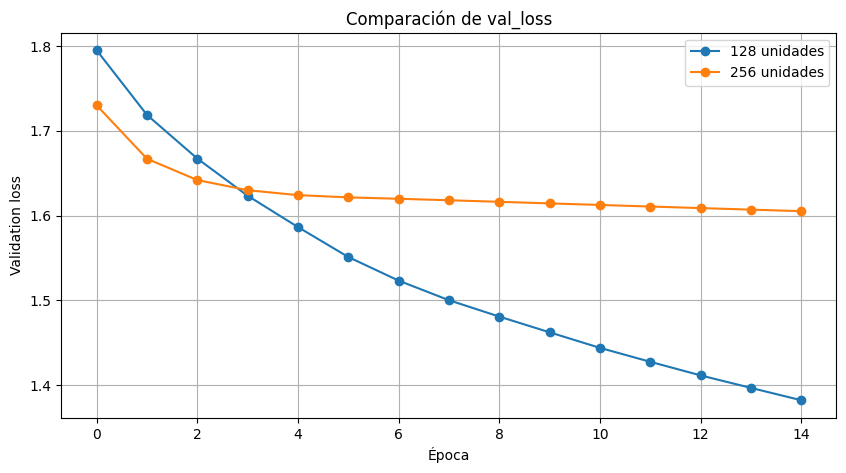

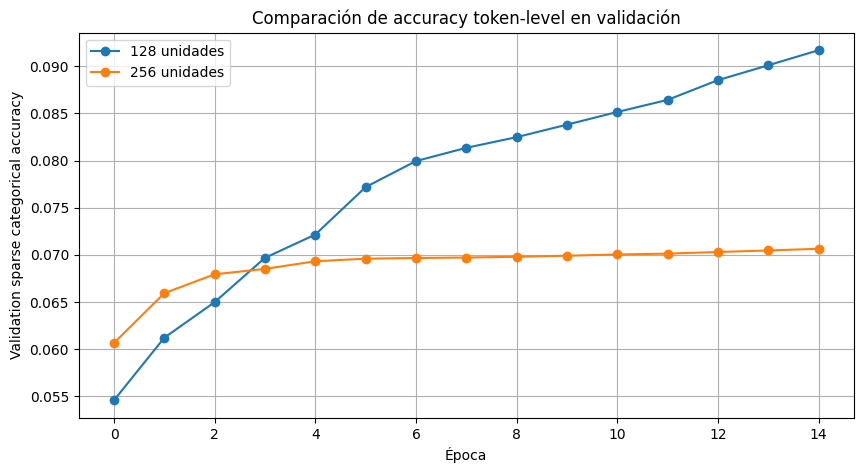

,units,best_epoch,best_val_loss,best_val_accuracy,val_perplexity
0,128,15,1.382303,0.091708,3.984065
1,256,15,1.605224,0.070644,4.978974


In [13]:
plt.figure(figsize=(10, 5))
for units in UNITS_TO_TEST:
    plt.plot(histories[units]["val_loss"], marker="o", label=f"{units} unidades")
plt.title("Comparación de val_loss")
plt.xlabel("Época")
plt.ylabel("Validation loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
for units in UNITS_TO_TEST:
    plt.plot(histories[units]["val_sparse_categorical_accuracy"], marker="o", label=f"{units} unidades")
plt.title("Comparación de accuracy token-level en validación")
plt.xlabel("Época")
plt.ylabel("Validation sparse categorical accuracy")
plt.legend()
plt.grid(True)
plt.show()

display(results_df)


Aunque el modelo de 256 unidades presenta mejores valores iniciales, su aprendizaje se estanca rápidamente. El modelo de 128 unidades mejora de forma sostenida tanto en pérdida como en accuracy, alcanzando el mejor desempeño final. Esto muestra que un modelo más grande no siempre implica mejores resultados, especialmente cuando el tamaño del corpus y la configuración de entrenamiento no justifican una mayor complejidad.

## 8. Modelos de inferencia

Durante entrenamiento, el decoder recibe la secuencia real desplazada (`teacher forcing`). Durante inferencia, el decoder genera una palabra por vez y su propia salida anterior se vuelve la próxima entrada.

Se implementan:

- Greedy decoding: elige siempre la palabra más probable.
- Beam search: mantiene varias hipótesis candidatas y elige la secuencia con mayor probabilidad acumulada.


In [14]:
best_units = int(results_df.iloc[0]["units"])
best_bundle = trained_bundles[best_units]

print("Mejor configuración según val_loss:", best_units, "unidades LSTM")

def build_inference_models(bundle):
    n_units = bundle["n_units"]

    # Encoder inference
    encoder_model = Model(
        bundle["encoder_inputs"],
        bundle["encoder_states"],
        name="encoder_inference"
    )

    # Decoder inference
    decoder_input_single = Input(shape=(1,), name="decoder_input_single")
    decoder_state_input_h = Input(shape=(n_units,), name="decoder_state_h")
    decoder_state_input_c = Input(shape=(n_units,), name="decoder_state_c")

    decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

    decoder_emb = bundle["decoder_embedding_layer"](decoder_input_single)

    decoder_outputs, state_h, state_c = bundle["decoder_lstm"](
        decoder_emb,
        initial_state=decoder_states_inputs
    )

    decoder_outputs = bundle["decoder_dense"](decoder_outputs)

    decoder_model = Model(
        [decoder_input_single] + decoder_states_inputs,
        [decoder_outputs, state_h, state_c],
        name="decoder_inference"
    )

    return encoder_model, decoder_model

encoder_model, decoder_model = build_inference_models(best_bundle)

idx2word_outputs = {v: k for k, v in word2idx_outputs.items()}
sos_idx = word2idx_outputs["<sos>"]
eos_idx = word2idx_outputs["<eos>"]

def decode_indices(indices):
    words = []
    for idx in indices:
        if idx == 0 or idx == sos_idx:
            continue
        if idx == eos_idx:
            break
        word = idx2word_outputs.get(idx, "")
        if word and word != "<unk>":
            words.append(word)
    return " ".join(words)

def encode_input_text(text):
    seq = input_tokenizer.texts_to_sequences([text])
    seq = pad_sequences(seq, maxlen=max_input_len, padding="pre", truncating="pre")
    return seq

def translate_greedy(text):
    input_seq = encode_input_text(text)
    states_value = encoder_model.predict(input_seq, verbose=0)

    target_seq = np.zeros((1, 1), dtype="int32")
    target_seq[0, 0] = sos_idx

    decoded_indices = []

    for _ in range(max_out_len):
        output_tokens, h, c = decoder_model.predict(
            [target_seq] + states_value,
            verbose=0
        )

        sampled_idx = int(np.argmax(output_tokens[0, 0, :]))

        if sampled_idx == eos_idx:
            break

        decoded_indices.append(sampled_idx)

        target_seq[0, 0] = sampled_idx
        states_value = [h, c]

    return decode_indices(decoded_indices)

def translate_beam_search(text, beam_width=3, alpha=0.7):
    input_seq = encode_input_text(text)
    initial_states = encoder_model.predict(input_seq, verbose=0)

    # Cada candidato: (tokens_generados, score_neg_log, states)
    candidates = [([sos_idx], 0.0, initial_states)]

    for _ in range(max_out_len):
        all_candidates = []

        for seq, score, states_value in candidates:
            last_token = seq[-1]

            if last_token == eos_idx:
                all_candidates.append((seq, score, states_value))
                continue

            target_seq = np.zeros((1, 1), dtype="int32")
            target_seq[0, 0] = last_token

            output_tokens, h, c = decoder_model.predict(
                [target_seq] + states_value,
                verbose=0
            )

            probs = output_tokens[0, 0, :]
            top_indices = np.argsort(probs)[-beam_width:]

            for idx in top_indices:
                prob = max(float(probs[idx]), 1e-12)
                new_seq = seq + [int(idx)]
                new_score = score - np.log(prob)
                all_candidates.append((new_seq, new_score, [h, c]))

        def normalized_score(candidate):
            seq, score, _ = candidate
            length = max(1, len(seq))
            return score / (length ** alpha)

        candidates = sorted(all_candidates, key=normalized_score)[:beam_width]

        if all(seq[-1] == eos_idx for seq, _, _ in candidates):
            break

    best_seq = candidates[0][0]
    return decode_indices(best_seq)


Mejor configuración según val_loss: 128 unidades LSTM


## 9. Ejemplos de traducción

Se presentan al menos cinco traducciones generadas por el modelo entrenado, tal como pide la consigna.

Se muestran tanto ejemplos del dataset como oraciones nuevas.


In [15]:
test_sentences = [
    "I want to eat an apple.",
    "Where is the nearest train station?",
    "She plays the piano very well.",
    "I have never seen that before.",
    "Can you help me?",
    "My mother says hello.",
    "We are learning artificial intelligence."
]

print("\nTraducciones con Greedy Search")
print("-"*70)
for text in test_sentences:
    print("EN:", text)
    print("ES:", translate_greedy(text))
    print()

print("\nTraducciones con Beam Search")
print("-"*70)
for text in test_sentences[:5]:
    print("EN:", text)
    print("ES:", translate_beam_search(text, beam_width=3))
    print()

print("\nEjemplos tomados del dataset de validación")
print("-"*70)
for _ in range(5):
    i = np.random.randint(0, len(Xenc_val))
    source_text = input_sentences[split_idx + i]
    target_real = target_sentences[split_idx + i].replace(" <eos>", "")
    pred = translate_greedy(source_text)

    print("EN:", source_text)
    print("ES real:", target_real)
    print("ES pred:", pred)
    print()



Traducciones con Greedy Search
----------------------------------------------------------------------
EN: I want to eat an apple.
ES: me gusta una de la noche

EN: Where is the nearest train station?
ES: el es un de

EN: She plays the piano very well.
ES: no me gusta la

EN: I have never seen that before.
ES: me gusta una de

EN: Can you help me?
ES: me gusta la noche

EN: My mother says hello.
ES: el es muy

EN: We are learning artificial intelligence.
ES: me gusta una


Traducciones con Beam Search
----------------------------------------------------------------------
EN: I want to eat an apple.
ES: me gustaría que te

EN: Where is the nearest train station?
ES: el es una de

EN: She plays the piano very well.
ES: él es un poco de

EN: I have never seen that before.
ES: me gusta una de

EN: Can you help me?
ES: te


Ejemplos tomados del dataset de validación
----------------------------------------------------------------------
EN: I think you'll like it too.
ES real: Pienso que a t

## 10. Interpretación de resultados


In [17]:
best_row = results_df.iloc[0]

print("Resumen automático de resultados")
print("-"*70)
print(f"Mejor modelo: LSTM con {int(best_row['units'])} unidades")
print(f"Mejor época: {int(best_row['best_epoch'])}")
print(f"Validation loss mínima: {best_row['best_val_loss']:.4f}")
print(f"Validation accuracy máxima: {best_row['best_val_accuracy']:.4f}")
print(f"Perplejidad de validación: {best_row['val_perplexity']:.4f}")




Resumen automático de resultados
----------------------------------------------------------------------
Mejor modelo: LSTM con 128 unidades
Mejor época: 15
Validation loss mínima: 1.3823
Validation accuracy máxima: 0.0917
Perplejidad de validación: 3.9841


Se observa que el modelo con 128 unidades LSTM tuvo un mejor desempeño que el modelo con 256 unidades. Si bien el modelo de 256 unidades comenzó el entrenamiento con una menor pérdida de validación, su mejora se estabilizó a partir de la tercera época luego de las primeras épocas. En cambio, el modelo de 128 unidades mostró una evolución más sostenida, reduciendo progresivamente la val_loss y aumentando la accuracy token-level durante todo el entrenamiento.

El modelo de 128 unidades, al ser más simple, parece haber alcanzado un mejor equilibrio entre capacidad de aprendizaje y generalización. Esto demuestra que aumentar la complejidad del modelo no siempre implica obtener mejores resultados, especialmente en tareas de traducción Seq2Seq con datasets acotados y arquitecturas recurrentes básicas.
